In [1]:
from pathlib import Path
import time
import datasets
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "2"

#import torch
#from tokenizers import BertWordPieceTokenizer, Regex, normalizers
#from transformers import (
#    BertConfig,
#    BertForMaskedLM,
#    BertTokenizerFast,
#)
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
import numpy as np
import chromadb
#3print(torch.__version__)
#print(torch.cuda.is_available())

#client = chromadb.PersistentClient(path="/home/sergeev/PythonScripts/NLP/Bert/ru_newspappers_99//ChromaDB_store_99")
client = chromadb.PersistentClient(path="c:/Users/PC1/Documents/PythonScripts/NLP/Bert/ru_newspappers_2010-2014//ChromaDB_store_10-14")
collections = client.list_collections()
print(f"My chromaDB collections {collections}")
#collection_name = "RU99-2009_1" # "RU99-2009_1" - collection with all sentenses with words Russia and US in all forms
#collection_name = "RU99-2009_run_20250625" #- collection with "inglhardt": tradition, survavil, cultrue...
collection_name = "RNP_run_20250718_model_lim10k"
try:
    collection = client.get_collection(name=collection_name)
    print(f"Collection '{collection_name}' loaded.")
except ValueError:
    print(f"Collection '{collection_name}' not found.  Make sure the database exists and the collection name is correct.")
    exit() 
print(f"collection.count() {collection.count()}")
#print(f" collection.peek() {collection.peek()}")

C:\Users\PC1\anaconda3\envs\emb\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


My chromaDB collections [Collection(name=RNP_run_20250718_model_lim10k), Collection(name=RU99-2009_run_20250718_50k), Collection(name=RU99-2009_run_20250718_s50k_100k)]
Collection 'RNP_run_20250718_model_lim10k' loaded.
collection.count() 117381


In [2]:

X_ini = collection.get(include=["embeddings", "documents", "metadatas"],
    where={
    #"Базовая форма": {"$in": ["разум"]},
    "Базовая форма": {"$in": ["Россия"]},
        #"Базовая форма": {"$in": ["РФ"]},
        #"Базовая форма": {"$in": ["традиция"]},
        #"Базовая форма": {"$in": ["выжить"]},
    }
) 
loaded_df = pd.DataFrame({'Индекс': X_ini['ids'],
                           'Предложение': X_ini['documents'],
                           'Эмбеддинг': X_ini['embeddings'].tolist()}) 
                          #'Эмбеддинг': X_ini['embeddings']}) 
loaded_df['Эмбеддинг'] = loaded_df['Эмбеддинг'].apply(lambda x: np.array(x))
#print(loaded_df)
data = {}
metadata_keys = list(X_ini['metadatas'][0].keys()) # Получаем ключи из первого элемента
for key in metadata_keys:
    data[key] = [metadata[key] for metadata in X_ini['metadatas']]  # Добавляем колонки из метаданных
rest_df = pd.DataFrame(data)
df = pd.concat([loaded_df, rest_df], axis=1)

#X = loaded_df["Эмбеддинг"].to_numpy()
X = np.stack(loaded_df['Эмбеддинг'].to_numpy())  
#X = np.array(X_ini["embeddings"])
print(X)
print(type(X))

[[ 2.50736356  3.20143604 -1.40410197 ...  0.6672833  -0.85525101
   0.10002035]
 [ 4.61243725 -0.87005734  2.80083513 ...  0.2854577  -3.64904952
   1.45968533]
 [ 1.19030499 -0.11362714 -4.51532269 ...  0.78241599  2.56071806
  -4.77321959]
 ...
 [ 5.14508772 -1.11408734 -2.37957382 ... -1.81626153 -3.95234823
  -2.42861795]
 [ 3.75467157 -1.66744947  1.99594986 ...  0.81009209 -0.46065685
  -0.03378996]
 [ 4.28412533  0.56013894 -1.36111641 ...  3.31382442 -1.52524126
  -3.96530175]]
<class 'numpy.ndarray'>


Оптимальное количество кластеров: 10


C:\Users\PC1\anaconda3\envs\emb\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC1\anaconda3\envs\emb\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Количество кластеров DBscan: 75
Количество шумовых точек DBscan: 7916


C:\Users\PC1\anaconda3\envs\emb\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Temp\ipykernel_14200\304945507.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


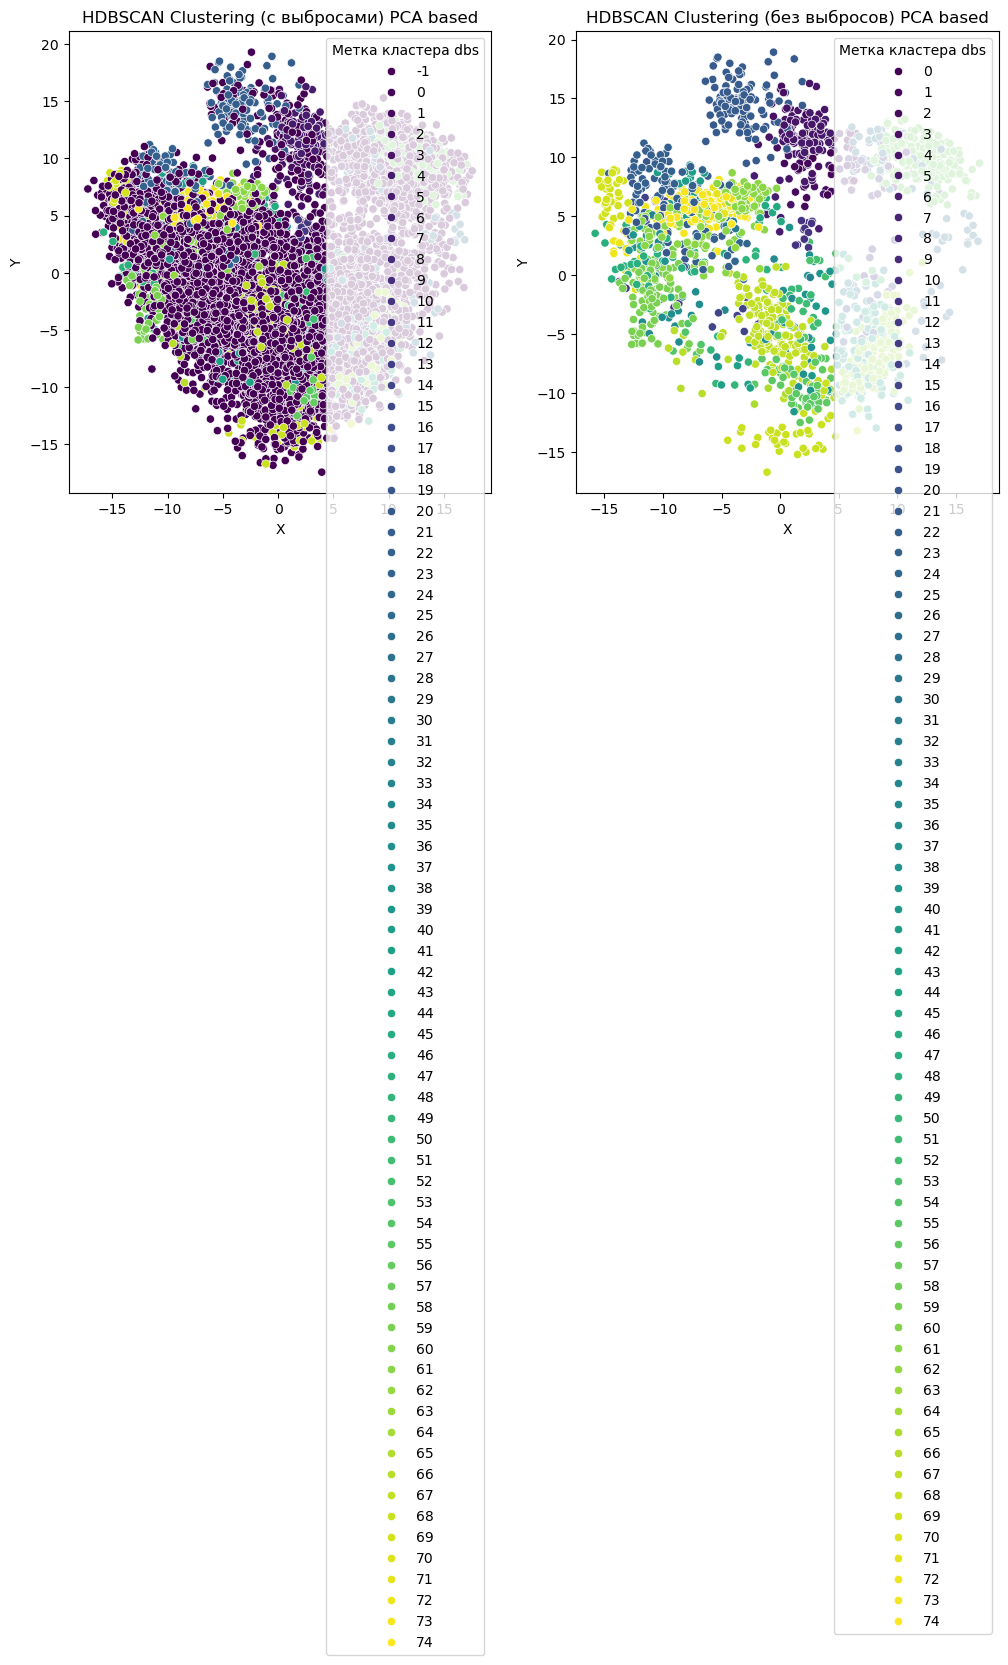

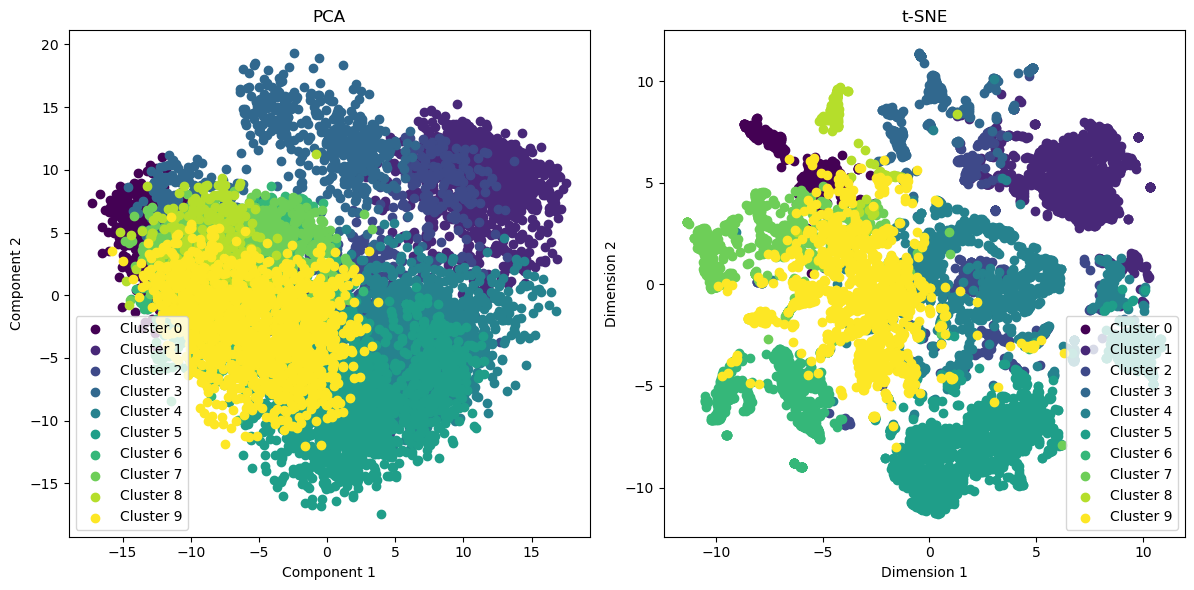


Оценка Silhouette Score для KMeans кластеризации:
Silhouette Score: 0.0682

Оценка Silhouette Score для DBscan кластеризации:
Silhouette Score: -0.1450


In [11]:
import pandas as pd
import numpy as np
#from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Методы уменьшения размерности
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
#import umap

import matplotlib.pyplot as plt
import seaborn as sns  

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import hdbscan

random_state = 42
# 1. Создание синтетических данных (как пример, теперь без меток)
# n_samples = 500
# n_features = 50
# X, _ = make_blobs(n_samples=n_samples, n_features=n_features, centers=3, random_state=random_state) # Без labels_true

# Преобразуем в DataFrame (для удобства)
#df = pd.DataFrame(X)  # DataFrame без 'True Labels' колонки
#print(df)
# 2. Масштабирование данных (ВАЖНО для многих методов)
scaler = StandardScaler()
#scaled_data = scaler.fit_transform(df)  # Масштабируем весь DataFrame
scaled_data = scaler.fit_transform(X)  # Масштабируем весь DataFrame

# 3. Определение оптимального количества кластеров (KMeans + Silhouette Score)
range_n_clusters = range(2, 11) # Пробуем от 2 до 10 кластеров
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init = 'auto', random_state=random_state)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Выбираем оптимальное количество кластеров на основе Silhouette Score
optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров: {optimal_n_clusters}")

# Обучаем KMeans с оптимальным количеством кластеров
kmeans = KMeans(n_clusters=optimal_n_clusters, n_init = 'auto', random_state=random_state)
cluster_labels = kmeans.fit_predict(scaled_data)
df['Метка кластера KM'] = cluster_labels  # Добавляем колонку с метками кластеров

# 3. Кластеризация с помощью HDBSCAN
min_cluster_size = 5  # Настройка по необходимости
min_samples = 5
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                           metric='euclidean')
clusterer.fit(scaled_data)
cluster_labels = clusterer.labels_
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Количество кластеров DBscan: {n_clusters}")
print(f"Количество шумовых точек DBscan: {list(cluster_labels).count(-1)}")
df['Метка кластера dbs'] = cluster_labels



# 4. Применение методов уменьшения размерности
# 4.1 PCA
pca = PCA(n_components=2) # Уменьшаем до 2 компонент для визуализации
pca_result = pca.fit_transform(scaled_data)

# 4.2 t-SNE
tsne = TSNE(n_components=2, random_state=random_state, perplexity=30, n_iter=300) # Настраиваем параметры
tsne_result = tsne.fit_transform(scaled_data)

# 4.3 UMAP
#umap_reducer = umap.UMAP(n_components=2, random_state=random_state, n_neighbors=15, min_dist=0.1) # Настраиваем параметры
#umap_result = umap_reducer.fit_transform(scaled_data)

# 5. Визуализация результатов
df_plot = pd.DataFrame(pca_result, columns = ["X", "Y"])
df_plot['Метка кластера dbs'] = df['Метка кластера dbs']
#print(df_plot)
#print(len(df_plot))
outlier_indices = df[df['Метка кластера dbs'] == -1].index # индексы шумовых точек (выбросов)
df_no_outliers = df_plot.drop(outlier_indices) # удаляем строки с выбросами

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='X', y ='Y', data=df_plot, hue='Метка кластера dbs', palette='viridis', legend='full')
plt.title('HDBSCAN Clustering (с выбросами) PCA based')
plt.subplot(1, 2, 2)
sns.scatterplot(x='X', y ='Y', data=df_no_outliers, hue='Метка кластера dbs', palette='viridis', legend='full')
plt.title('HDBSCAN Clustering (без выбросов) PCA based')

plt.tight_layout()
plt.show()


plt.figure(figsize=(18, 6))

# Цветовая палитра
colors = plt.cm.viridis(np.linspace(0, 1, optimal_n_clusters))  # Создаем цветовую палитру
#print(f" colors {colors}")
# 5.1 PCA
plt.subplot(1, 3, 1)
for i in range(optimal_n_clusters):
    #plt.scatter(pca_result[df['Метка кластера'] == i, 0], pca_result[df['Метка кластера'] == i, 1],
    plt.scatter(pca_result[df['Метка кластера KM'] == i, 0], pca_result[df['Метка кластера KM'] == i, 1],
                color=colors[i], label=f'Cluster {i}')
plt.title('PCA')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()

# 5.2 t-SNE
plt.subplot(1, 3, 2)
for i in range(optimal_n_clusters):
    #plt.scatter(tsne_result[df['Метка кластера'] == i, 0], tsne_result[df['Метка кластера'] == i, 1],
    plt.scatter(tsne_result[df['Метка кластера KM'] == i, 0], tsne_result[df['Метка кластера KM'] == i, 1],
                color=colors[i], label=f'Cluster {i}')
plt.title('t-SNE')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# 5.3 UMAP
# plt.subplot(1, 3, 3)
# for i in range(optimal_n_clusters):
#     plt.scatter(umap_result[df['Cluster Labels'] == i, 0], umap_result[df['Cluster Labels'] == i, 1],
#                 color=colors[i], label=f'Cluster {i}')
# plt.title('UMAP')
# plt.xlabel('Dimension 1')
# plt.ylabel('Dimension 2')
# plt.legend()

plt.tight_layout()
plt.show()


# 6. Оценка Silhouette Score для найденных кластеров
print("\nОценка Silhouette Score для DBscan кластеризации:")
silhouette_avg = silhouette_score(scaled_data, df_plot['Метка кластера dbs'])
print(f"Silhouette Score: {silhouette_avg:.4f}")
print("\nОценка Silhouette Score для KMeans кластеризации:")
silhouette_avg = silhouette_score(scaled_data, df['Метка кластера KM'])
print(f"Silhouette Score: {silhouette_avg:.4f}")



In [197]:
df

,Индекс,Предложение,Эмбеддинг,Искомая форма,Базовая форма,Метка кластера,Метка кластера dbs
0,460,"Подразумевается, разумеется, бронзовые.","[0.8277772068977356, -1.8595937490463257, 3.16...",разумеется,разум,0,-1
1,1203,"Разумеется, Россия может и не рассматривать ак...","[1.2868876457214355, 2.4676055908203125, -1.09...",разумеется,разум,0,74
2,1678,"Разумеется, предложенный проект пройдет обсужд...","[-0.2267332375049591, 0.1212448999285698, 1.46...",разумеется,разум,0,74
3,1863,"Собственные БКИ имеют, например, Сбербанк и «Р...","[-0.2255123108625412, -3.6597745418548584, 2.4...",разумеется,разум,0,-1
4,1927,"Интерьерам памятника истории, разумеется, обно...","[0.061328187584877014, -1.9376208782196045, 1....",разумеется,разум,0,-1
...,...,...,...,...,...,...,...
9995,1860215,"— Разумеется, у евреев и арабов много общего, ...","[4.026439666748047, -1.0502393245697021, -0.12...",разумеется,разум,0,-1
9996,1860230,"Разумеется, не напрямую.","[1.7994507551193237, -1.0221519470214844, -1.2...",разумеется,разум,0,-1
9997,1860270,"Мы считаем, например, что из этого списка долж...","[2.6888744831085205, -1.0292210578918457, 0.24...",разумеется,разум,0,-1
9998,1860429,"Его координаты она, разумеется, не сообщила (к...","[-0.8852488398551941, -3.042973756790161, 0.77...",разумеется,разум,0,-1


### Рассмотрим первые предложения для каждого из кластеров

In [186]:
for i in set(cluster_labels):
    print(f"cluster {i}")
    #print(df.loc[df['Метка кластера'] == i, ["Предложение", "Искомая форма"]][0:3])
    dft = df[df['Метка кластера'] == i]
    dft = dft["Предложение"]
    #print(dft.loc[i:i].to_string())
    dft = dft.reset_index(drop=True)
    print(f"0 {dft[0]}")
    print(f"1 {dft[1]}")
    print(f"2 {dft[2]}")
    print(f"3 {dft[3]}")


cluster 0
0 Подразумевается, разумеется, бронзовые.
1 Разумеется, Россия может и не рассматривать активно золотой стандарт, но Владимир Путин демонстрирует все признаки стремительной концентрации политического и экономического контроля над евразийским регионом при одновременном отходе от Америки и Западной Европы.
2 Разумеется, предложенный проект пройдет обсуждение и будет представлен на экспертном совете", - отметил Метельский.
3 Собственные БКИ имеют, например, Сбербанк и «Русский стандарт» (они, разумеется, находятся в столице).
cluster 1
0 «Там единоличные качества должны опираться на коллективный разум Генштаба, и если это так, тогда гражданскому министру легко управлять вооруженными силами», – сказал Анатолий Лопата.
1 «Там единоличные качества должны опираться на коллективный разум Генштаба, и если это так, тогда гражданскому министру легко управлять вооруженными силами», – сказал Анатолий Лопата.
2 Публикуется по материалам PR-агентства Непрерывная истерия в стане караул-патри

### Поиск характерных для каждого из кластеров предложений

In [187]:
emb_store = []
for i in set(cluster_labels):
    print(f"cluster {i}")
    #print(df.loc[df['Метка кластера'] == i, ["Предложение", "Искомая форма"]][0:3])
    dft = df[df['Метка кластера'] == i]
    Xt = np.stack(dft['Эмбеддинг'].to_numpy())  
    print(len(Xt))
    lent = len(Xt)
    Xt = Xt.sum(axis = 0)
    Xt = Xt/lent # центральный эмбеддинг кластера
    emb_store.append(Xt)
    # Найдем ближайших соседей как наиболее характерные для данного кластера
    results = collection.query(
            query_embeddings=Xt, # ChromaDB принимает список эмбеддингов
            n_results=3
        )
    print(results['documents'])

cluster 0
8836
[['Разумеется, за это время у него была и другая работа.', 'Разумеется, она не тянула бы на полноценное «житие», как это обозначено в нынешнем заголовке: для настоящей агиографии требуется больше источников, да и селекция не помешала бы.', 'Разумеется, амстердамцы претендуют на чемпионство и в этом сезоне.']]
cluster 1
1164
[['Главное, что сейчас идет битва идей и образов и надо стараться, чтобы в этой схватке все-таки победил разум.', 'Главное, что сейчас идет битва идей и образов и надо стараться, чтобы в этой схватке все-таки победил разум.', 'А рисунку нужен разум, способный медитировать и созерцать».']]


### Рассмотрим расстояние между центральными векторами выделенных кластеров (emb_store)

In [192]:
cluster_labels_set_len = len(set(cluster_labels))
for i in range(cluster_labels_set_len-1):
    #cluster_labels_set.remove(i)
    for j in range(i, cluster_labels_set_len):
        print(f" {i} {j} {cosine_similarity([emb_store[i]], [emb_store[j]])}")

 0 0 [[1.]]
 0 1 [[0.45639012]]


C:\Users\PC1\anaconda3\envs\emb\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\PC1\anaconda3\envs\emb\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Количество кластеров: 3
Количество шумовых точек: 9
     Scaled Feature 1  Scaled Feature 2  HDBSCAN Labels
0           -1.196684         -1.360529               1
1           -1.255989         -1.309848               1
2           -0.083869          1.072302               0
3            1.272549          0.229333               2
4           -1.430143         -1.377765               1
..                ...               ...             ...
315          0.551753         -0.710064               2
316         -0.594263          0.501103               0
317          1.308212          0.282497               2
318         -0.088189         -0.823425              -1
319          0.713756         -0.290509               2

[320 rows x 3 columns]
Размер DataFrame до удаления выбросов: 320
Размер DataFrame после удаления выбросов: 311


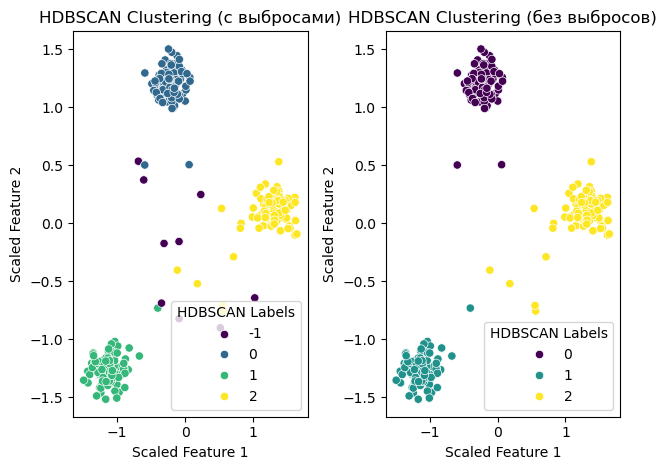

In [67]:
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import hdbscan
#import matplotlib.pyplot as plt
#import plotly.express as px
import seaborn as sns

# 1. Создание синтетических данных (замените своими!)
n_samples = 300
centers = 3
cluster_std = 0.7
random_state = 42

X, labels_true = make_blobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=random_state)

# Добавим немного выбросов
rng = np.random.RandomState(42)
n_outliers = 20
outliers = rng.uniform(low=-5, high=5, size=(n_outliers, 2))
X = np.vstack([X, outliers])  # добавляем выбросы к данным

df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

# 2. Масштабирование данных (ВАЖНО для HDBSCAN)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
df['Scaled Feature 1'] = scaled_features[:, 0]
df['Scaled Feature 2'] = scaled_features[:, 1]

# 3. Кластеризация с помощью HDBSCAN
min_cluster_size = 5  # Настройка по необходимости
min_samples = 5

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                           metric='euclidean')
clusterer.fit(scaled_features)

cluster_labels = clusterer.labels_
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {list(cluster_labels).count(-1)}")

df['HDBSCAN Labels'] = cluster_labels
df = df[['Scaled Feature 1', 'Scaled Feature 2', 'HDBSCAN Labels']]
print(df)

# 4. Идентификация и удаление выбросов
outlier_indices = df[df['HDBSCAN Labels'] == -1].index # индексы шумовых точек (выбросов)
df_no_outliers = df.drop(outlier_indices) # удаляем строки с выбросами

print(f"Размер DataFrame до удаления выбросов: {len(df)}")
print(f"Размер DataFrame после удаления выбросов: {len(df_no_outliers)}")

# 5. Визуализация (если данные двумерные)


# plt.figure(figsize=(18, 6))

# # Цветовая палитра
# colors = plt.cm.viridis(np.linspace(0, 1, optimal_n_clusters))  # Создаем цветовую палитру

# # 5.1 PCA
# plt.subplot(1, 3, 1)
# for i in range(optimal_n_clusters):
#     #plt.scatter(pca_result[df['Метка кластера'] == i, 0], pca_result[df['Метка кластера'] == i, 1],
#     plt.scatter(pca_result[df['Метка кластера dbs'] == i, 0], pca_result[df['Метка кластера dbs'] == i, 1],
#                 color=colors[i], label=f'Cluster {i}')
# plt.title('PCA')
# plt.xlabel('Component 1')
# plt.ylabel('Component 2')
# plt.legend()

# 5. Визуализация 
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Scaled Feature 1', y='Scaled Feature 2', data=df, hue='HDBSCAN Labels', palette='viridis', legend='full')
plt.title('HDBSCAN Clustering (с выбросами)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Scaled Feature 1', y='Scaled Feature 2', data=df_no_outliers, hue='HDBSCAN Labels', palette='viridis', legend='full')
plt.title('HDBSCAN Clustering (без выбросов)')

plt.tight_layout()
plt.show()

# fig = px.scatter(df_no_outliers,   
#                  color = 'HDBSCAN Labels',
#                  )
# fig.show()

# colors = plt.cm.viridis(np.linspace(0, 1, len(set(df['HDBSCAN Labels'])))) 
# print(colors)
# plt.figure(figsize=(12, 6))

# plt.subplot(1, 2, 1)
# #plt.scatter(df['Scaled Feature 1'], df['Scaled Feature 2'], color = df['HDBSCAN Labels'])
# for i in range(len(set(df['HDBSCAN Labels'])):
#     #plt.scatter(pca_result[df['Метка кластера'] == i, 0], pca_result[df['Метка кластера'] == i, 1],
#     plt.scatter(df['Scaled Feature 1'], df['Scaled Feature 2'],
#                 color=colors[i], label=f'Cluster {i}')
# plt.title('HDBSCAN Clustering (с выбросами)')

# plt.subplot(1, 2, 2)
# plt.scatter(x='Scaled Feature 1', y='Scaled Feature 2', data=df_no_outliers)
# plt.title('HDBSCAN Clustering (без выбросов)')

# plt.tight_layout()
# plt.show()
